### Interactive analysis of the scVI batch-corrected adata 

In [1]:
import numpy as np 
import pandas as pd
import scvi
import scanpy as sc
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import gc

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
%%time
adata = sc.read_h5ad("05_scvi_adata.h5ad")
adata

CPU times: user 17.1 s, sys: 4min 43s, total: 5min
Wall time: 6min 19s


AnnData object with n_obs × n_vars = 2923936 × 16115
    obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'dendrogram_leiden_scVI', 'hvg', 'leiden_scVI', 'leiden_scVI_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs'
    layers: 'counts', 'scvi_normalized'
    obsp: 'connectivities', 'distances'

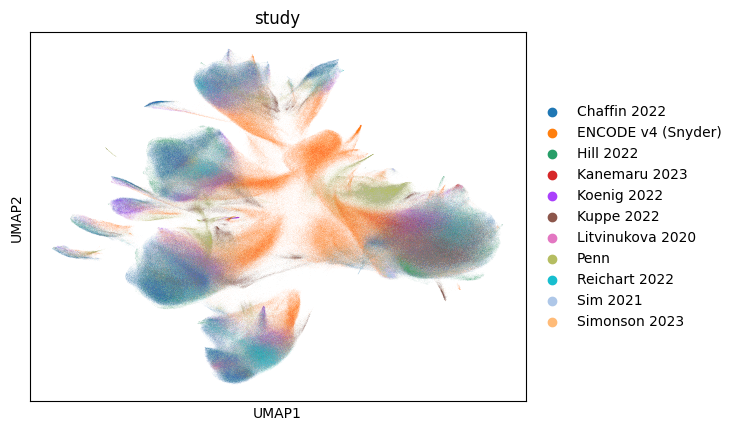

In [3]:
# check to see if there are good mixing of studies
sc.pl.umap(adata, color=["study"])

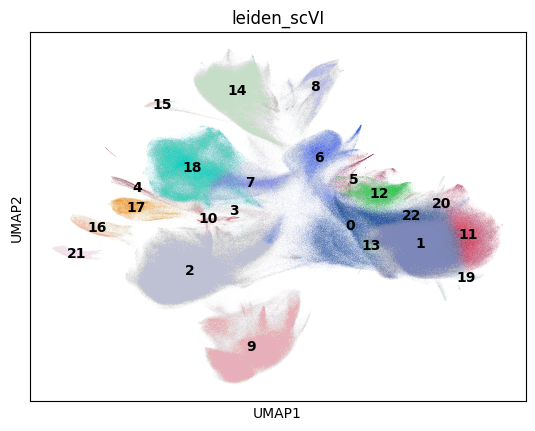

In [4]:
sc.pl.umap(adata, color=["leiden_scVI"], legend_loc = "on data")

### Examine the percentage of each leiden cluster per study

In [5]:
def produce_crosstab_barplot(metadata, cluster_label, metadata_column):
    '''Produce a barplot showing how the cluster_label (e.g. leiden) distributes according to a metadata column (e.g. study)'''

    prop_df = pd.crosstab(metadata[cluster_label], metadata[metadata_column])
    norm_prop_df = prop_df.div(prop_df.sum(axis = 1), axis = 0)

    ax = norm_prop_df.plot(kind = 'bar', stacked=True, figsize=(15, 5), colormap='tab20')
    ax.set_xlabel(cluster_label)
    ax.set_ylabel("Proportion")
    ax.set_title(f"Proportion per {cluster_label} grouped by {metadata_column}")

    # reverse the legend order so that it matches up with the barplot
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], title={cluster_label}, bbox_to_anchor=(1.05, 1), loc='upper left')

    # rotate the x labels
    plt.xticks(rotation=90, ha='right')
    return plt

In [6]:
adata_metadata = adata.obs

<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>

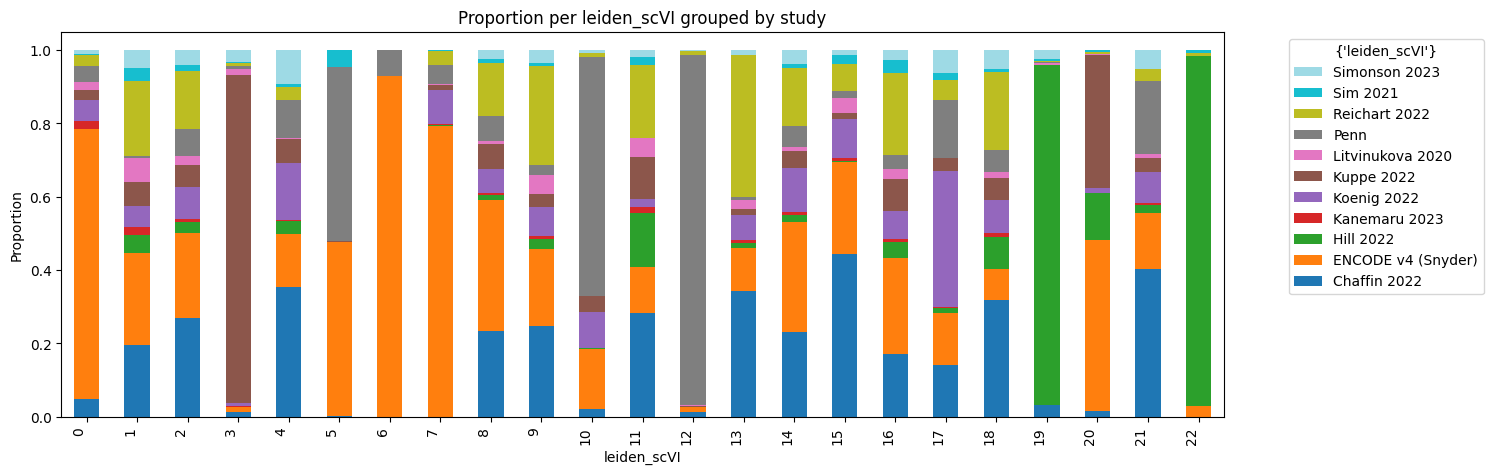

In [7]:
produce_crosstab_barplot(metadata = adata_metadata, cluster_label = 'leiden_scVI', metadata_column = 'study')

<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>

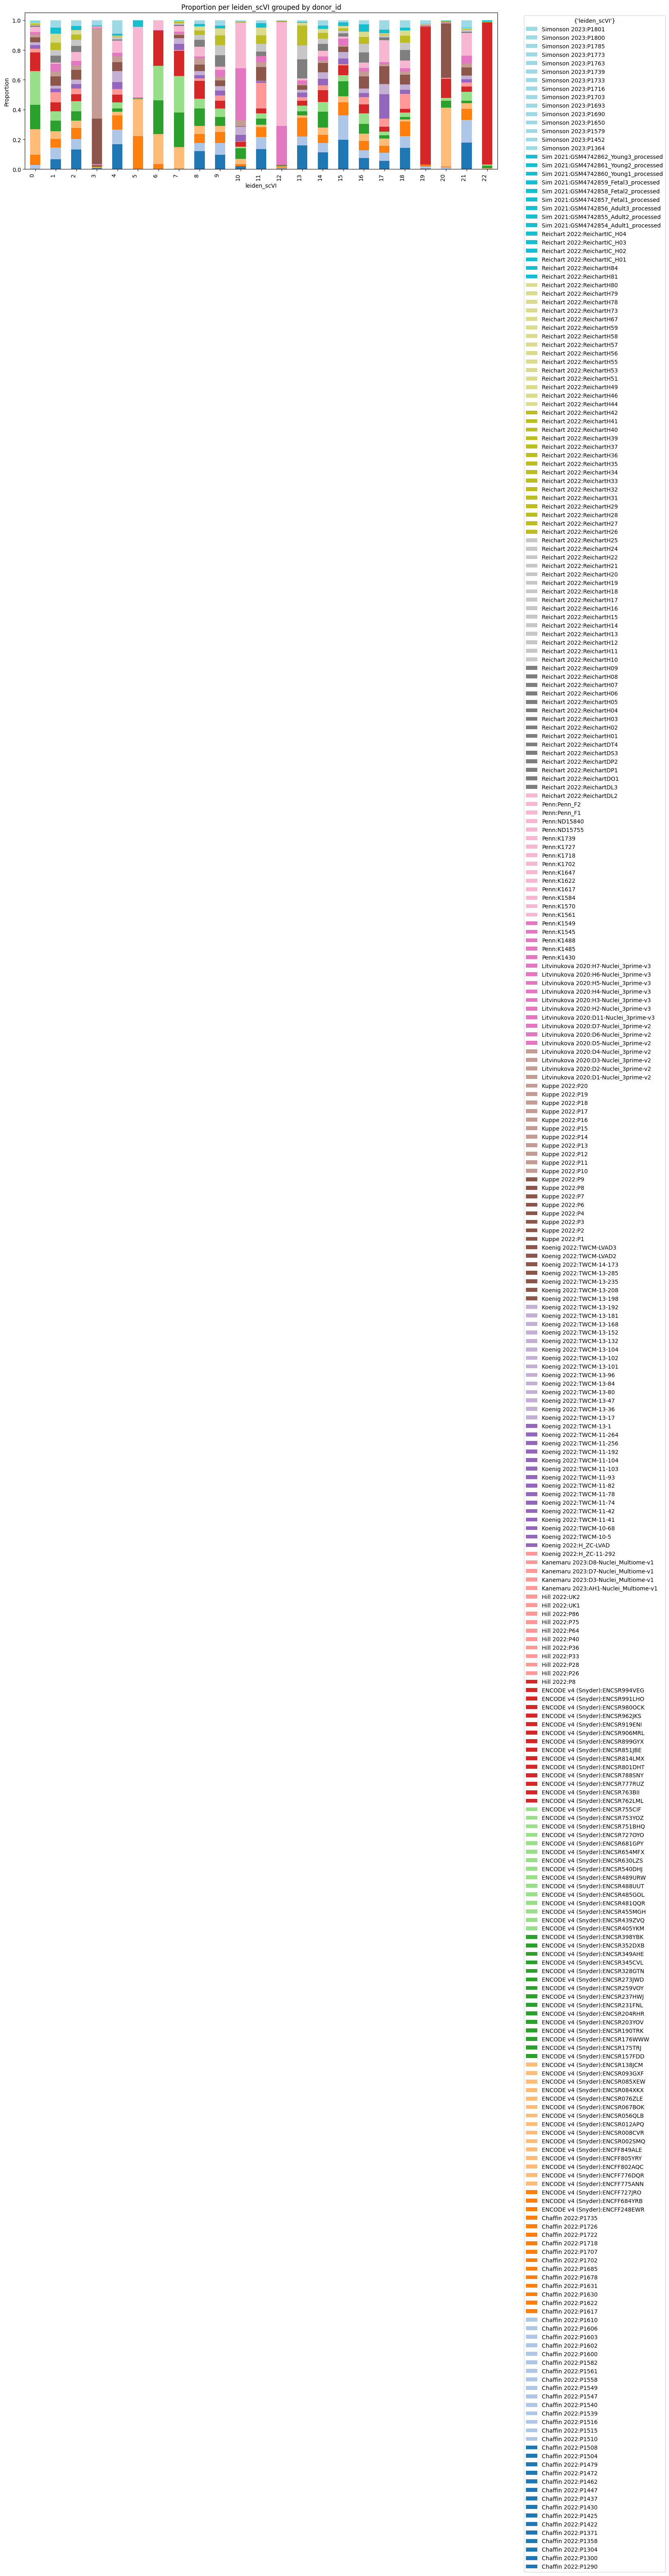

In [8]:
produce_crosstab_barplot(metadata = adata_metadata, cluster_label = 'leiden_scVI', metadata_column = 'donor_id')

<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>

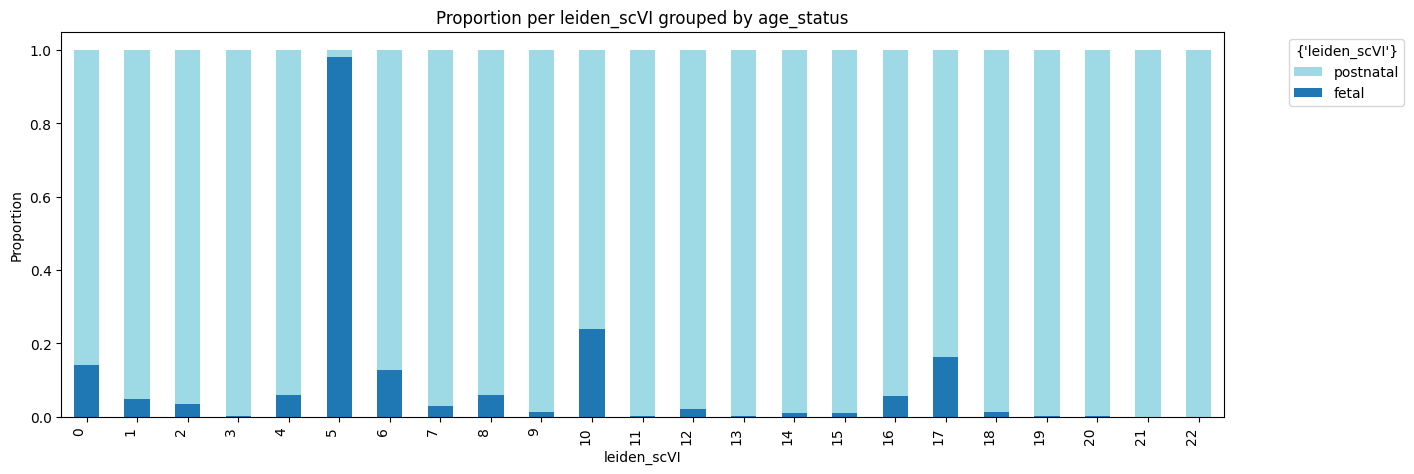

In [9]:
produce_crosstab_barplot(metadata = adata_metadata, cluster_label = 'leiden_scVI', metadata_column = 'age_status')

The following clusters with high proportions in only one study / high proportion in only a few donors will be dropped
- 0, 3, 6, 7, 19, 22

In [10]:
%%time
clusters_to_remove = ["0", "3", "6", "7", "19", "22"]
filtered_adata = adata[~adata.obs['leiden_scVI'].isin(clusters_to_remove), :]

CPU times: user 1.17 s, sys: 217 ms, total: 1.39 s
Wall time: 1.38 s


In [11]:
print(f"Number of nuclei removed from highly skewed clusters: {filtered_adata.shape[0] - adata.shape[0]}")

Number of nuclei removed from highly skewed clusters: -498460


Write this filtered adata and then load this back

In [12]:
%%time
filtered_adata.write("05B_filtered_scvi.h5ad")

CPU times: user 1min 16s, sys: 14min 43s, total: 15min 59s
Wall time: 16min 34s


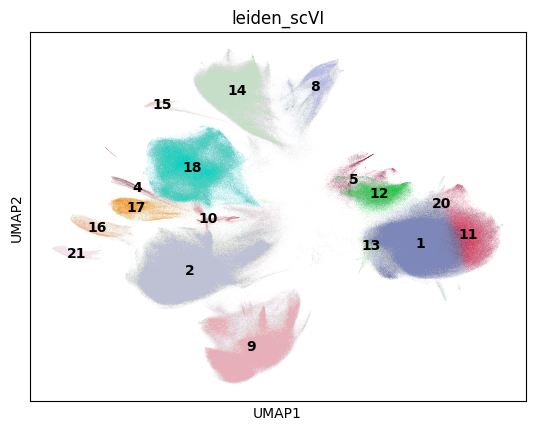

CPU times: user 7.69 s, sys: 572 ms, total: 8.26 s
Wall time: 8.08 s


In [13]:
%%time
sc.pl.umap(filtered_adata, color = "leiden_scVI", legend_loc = "on data")

### Restart the kernel here and load back the filtered adata

In [1]:
import numpy as np 
import pandas as pd
import scvi
import scanpy as sc
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import gc

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
%%time
filtered_adata = sc.read_h5ad("05B_filtered_scvi.h5ad")
filtered_adata

CPU times: user 18 s, sys: 3min 24s, total: 3min 42s
Wall time: 5min


AnnData object with n_obs × n_vars = 2425476 × 16115
    obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'dendrogram_leiden_scVI', 'hvg', 'leiden_scVI', 'leiden_scVI_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'study_colors', 'umap'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs'
    layers: 'counts', 'scvi_normalized'
    obsp: 'connectivities', 'distances'

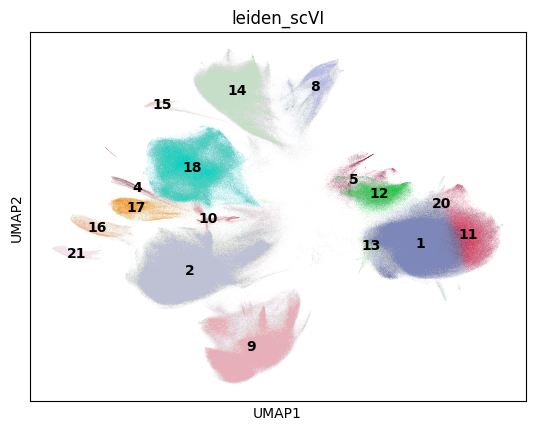

CPU times: user 12.6 s, sys: 605 ms, total: 13.2 s
Wall time: 12.9 s


In [3]:
%%time
sc.pl.umap(filtered_adata, color = "leiden_scVI", legend_loc = "on data")

### With the remaining clusters, perform cell type annotation

In [6]:
%%time
#sc.tl.dendrogram(filtered_adata, groupby="leiden_scVI")
#sc.pl.rank_genes_groups_dotplot(filtered_adata, groupby="leiden_scVI", standard_scale="var", n_genes=2, use_rep = "X")

CPU times: user 15 μs, sys: 0 ns, total: 15 μs
Wall time: 29.1 μs


In [28]:
# run this to identify top marker genes per cluster
#sc.get.rank_genes_groups_df(filtered_adata, group="9").head(20)

### Add cell type annotations in metadata field called "scvi_cell_type"

In [24]:
filtered_adata.obs["scvi_cell_type"] = filtered_adata.obs["leiden_scVI"].map(
    {
        "1": "Cardiomyocyte",
        "2": "Fibroblast",
        "4": "LEC",
        "5": "Cardiomyocyte",
        "8": "Lymphoid",
        "9": "Pericyte",
        "10": "Epicardial",
        "11": "Cardiomyocyte",
        "12": "Cardiomyocyte",
        "13": "Cardiomyocyte",
        "14": "Myeloid",
        "15": "Mast",
        "16": "Neuronal",
        "17": "Endocardial",
        "18": "Endothelial",
        "20": "Cardiomyocyte",
        "21": "Adipocyte",
    }
)

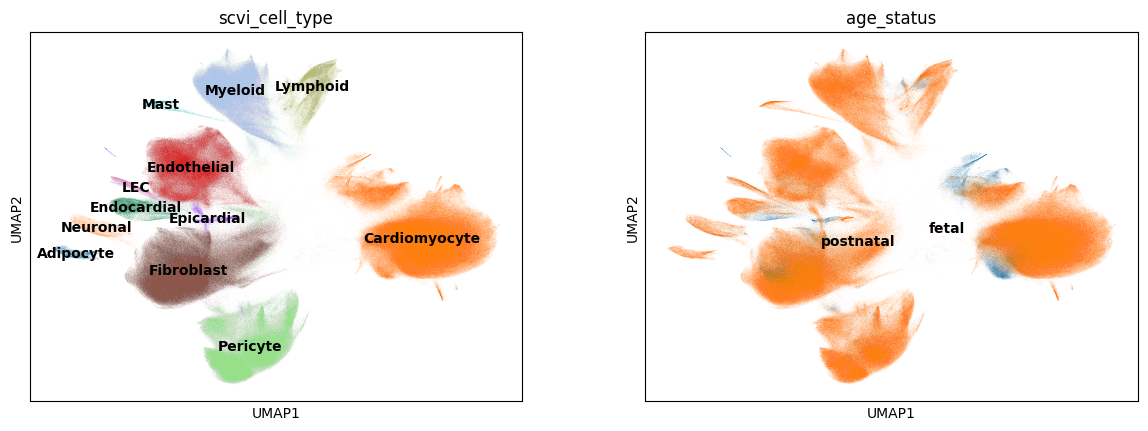

In [26]:
sc.pl.umap(filtered_adata, color=["scvi_cell_type", "age_status"], legend_loc = "on data")

#### Now, check the consistency of the annotations of the scVI leiden based cluster and the consistent cell type annotations (based on the original papers)

Examine the cell type proportions for each study

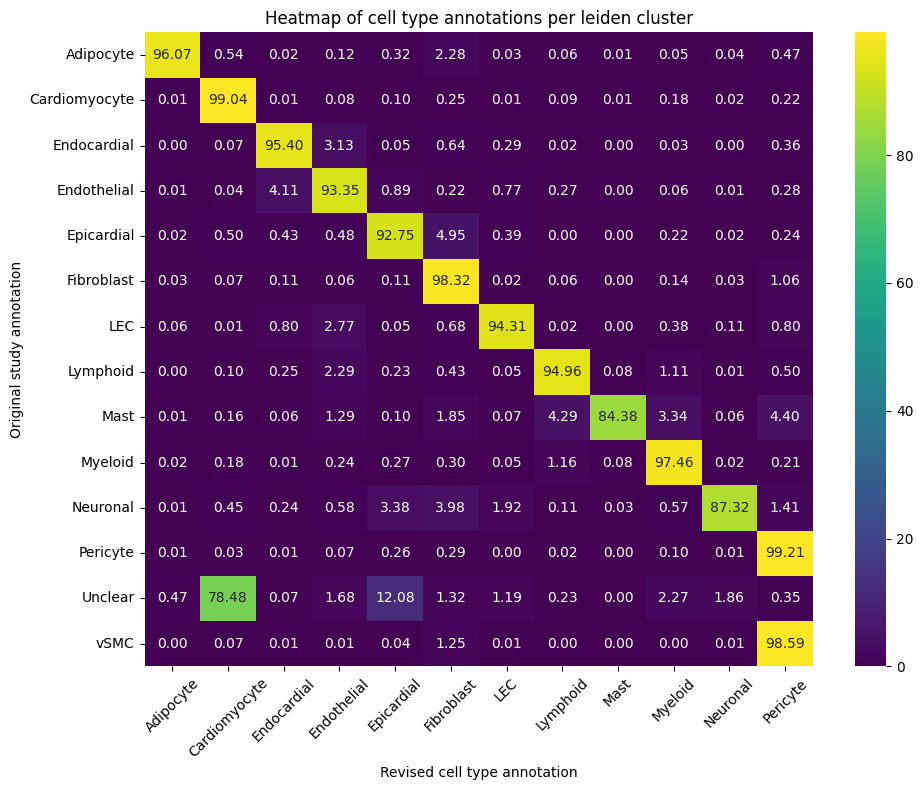

In [27]:
filtered_adata_metadata = filtered_adata.obs

# the first argument will be on the y-axis, while the second will be on the x-axis
consistency_matrix = pd.crosstab(filtered_adata_metadata['consistent_cell_type'], filtered_adata_metadata['scvi_cell_type'])
# normalize so that rows sum to 100%
norm_consistency_matrix = 100 * consistency_matrix.div(consistency_matrix.sum(axis = 1), axis = 0)
norm_consistency_matrix.head()

# plot the heatmap
plt.figure(figsize=(10, 8))  
sns.heatmap(norm_consistency_matrix, cmap='viridis', annot=True, fmt='.2f', cbar=True)
plt.title('Heatmap of cell type annotations per leiden cluster')
plt.xlabel('Revised cell type annotation')
plt.ylabel('Original study annotation')
plt.xticks(rotation=45)  
plt.yticks(rotation=0)   
plt.tight_layout()       
plt.show()   

### Will need to further split the leiden clusters

In [ ]:
%%time
filtered_adata.write("05B_filtered_scvi.h5ad")